# Multiple Linear Regression Modeling

### Research Question:

What are the most significant economic factors contributing to the death rate from drug overdose?

In [68]:
# Dependencies
library(here)
library(ggplot2)
library(dplyr)
library(leaps)
library(tidyr)
library(corrplot)
library(car)
library(lmtest)

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




In [42]:
# Load Data
df <- read.csv(here("data", "death_rate_scaled.csv"))
df$state <- as.factor(df$state)
head(df)
summary(df)

,year,state,pop,hydro_gms,oxy_gms,fent_gms,unempl_rate,poverty_rate,snap_rate,medicaid_rate,gsp_per_cap,min_wage,death_rate,log_hydro,log_oxy,log_fent,log_death_rate
,<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2000,AL,-0.2396840,-0.1037009,-0.07198984,-0.08602873,-0.73962867,0.1942059,-0.38573312,-0.62386327,-1.6618041,-1.026754,-1.308400,-0.3974345,-0.9192862,-0.9234053,-1.787006
2,2001,AL,-0.2373706,-0.1035686,-0.07195101,-0.08602885,-0.49287538,0.9488591,-0.31689900,-0.18631157,-1.6108019,-1.026754,-1.241686,-0.3637661,-0.8364945,-0.9250998,-1.627562
3,2002,AL,-0.2355071,-0.1032225,-0.07193209,-0.08601729,-0.13312766,0.5559496,-0.16282797,0.06299210,-1.5138153,-1.026754,-1.262992,-0.2837199,-0.8000439,-0.7838532,-1.677258
4,2003,AL,-0.2320056,-0.1028859,-0.07191409,-0.08600594,-0.07274793,0.6885560,-0.03373072,0.09102397,-1.4083021,-1.026754,-1.317015,-0.2149542,-0.7673390,-0.6757568,-1.808450
5,2004,AL,-0.2279301,-0.1025557,-0.07189656,-0.08599476,-0.22717372,1.3322157,0.07729171,0.21132943,-1.1632969,-1.026754,-1.001213,-0.1543956,-0.7371711,-0.5882937,-1.132110
6,2005,AL,-0.2220834,-0.1022392,-0.07188020,-0.08598392,-0.83051811,1.2020409,0.35266288,0.28930908,-0.9977787,-1.026754,-1.004699,-0.1015865,-0.7103351,-0.5160579,-1.138560


      year          state          pop            hydro_gms       
 Min.   :2000   AK     : 17   Min.   :-0.8319   Min.   :-0.10563  
 1st Qu.:2004   AL     : 17   1st Qu.:-0.6369   1st Qu.:-0.10452  
 Median :2008   AR     : 17   Median :-0.2592   Median :-0.10325  
 Mean   :2008   AZ     : 17   Mean   : 0.0000   Mean   : 0.00000  
 3rd Qu.:2012   CA     : 17   3rd Qu.: 0.1140   3rd Qu.:-0.09761  
 Max.   :2016   CO     : 17   Max.   : 4.9545   Max.   :20.15423  
                (Other):748                                       
    oxy_gms            fent_gms         unempl_rate       poverty_rate    
 Min.   :-0.07219   Min.   :-0.08604   Min.   :-1.8114   Min.   :-2.4119  
 1st Qu.:-0.07186   1st Qu.:-0.08600   1st Qu.:-0.7015   1st Qu.:-0.7649  
 Median :-0.07143   Median :-0.08594   Median :-0.2092   Median :-0.1545  
 Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.:-0.07013   3rd Qu.:-0.08564   3rd Qu.: 0.5115   3rd Qu.: 0.6633  
 Max.   :24.43

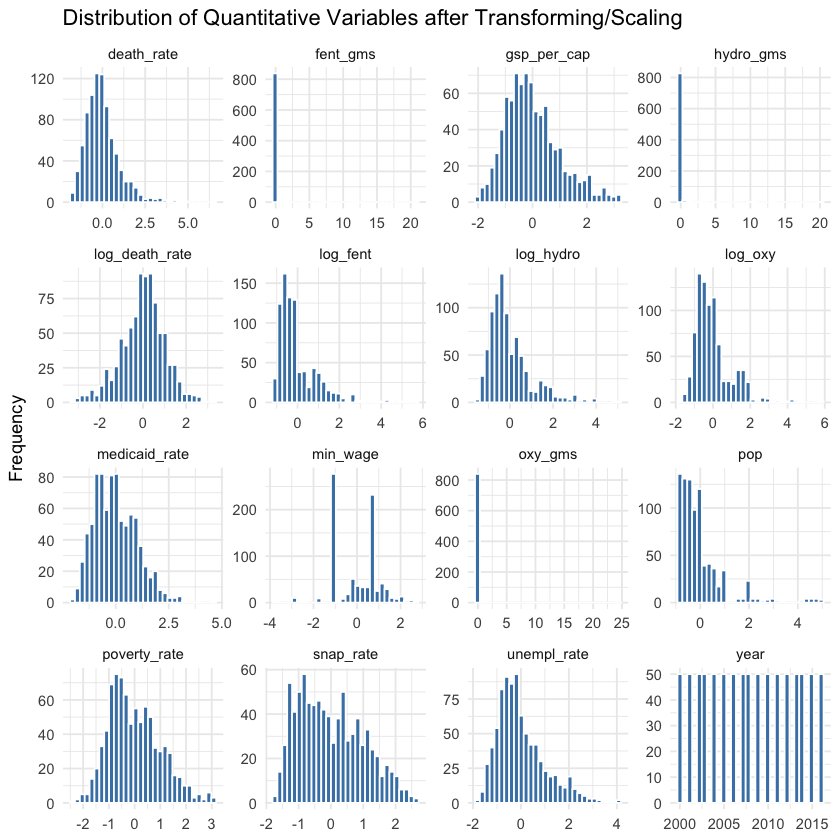

In [43]:
# Histograms for Numeric Variables
df |>
  select(where(is.numeric)) |>
  pivot_longer(cols = everything(),
               names_to = "variable",
               values_to = "value") |>
  ggplot(aes(x = value)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  facet_wrap(~variable, scales = "free") +
  theme_minimal() +
  labs(title = "Distribution of Quantitative Variables after Transforming/Scaling",
       x = NULL,
       y = "Frequency")

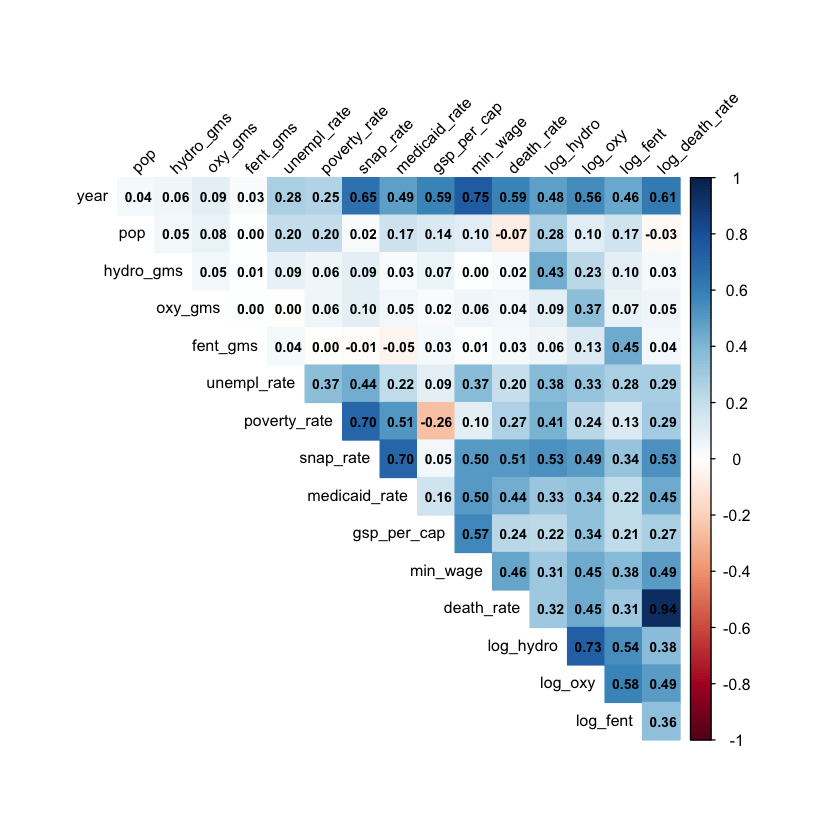

In [44]:
# Correlation Plot
cor_matrix <- df |>
  select(where(is.numeric)) |>
  cor(use = "complete.obs")

corrplot(cor_matrix,
         method = "color",
         type = "upper",
         addCoef.col = "black",
         number.cex = 0.7,
         tl.cex = 0.8,
         tl.col = "black",
         tl.srt = 45,
         diag = FALSE)

`geom_smooth()` using formula = 'y ~ x'


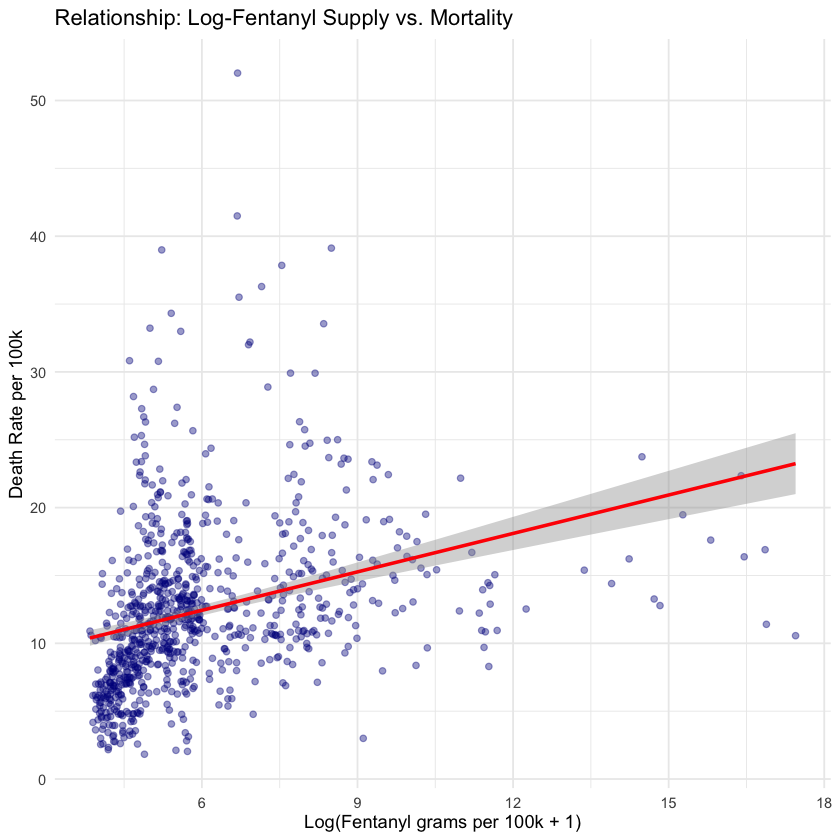

In [40]:
# Scatter plot of Log Fentanyl vs Death Rate
ggplot(df, aes(x = log_fent, y = death_rate)) +
  geom_point(alpha = 0.4, color = "darkblue") +
  geom_smooth(method = "lm", color = "red") + 
  labs(title = "Relationship: Log-Fentanyl Supply vs. Mortality",
       x = "Log(Fentanyl grams per 100k + 1)",
       y = "Death Rate per 100k") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


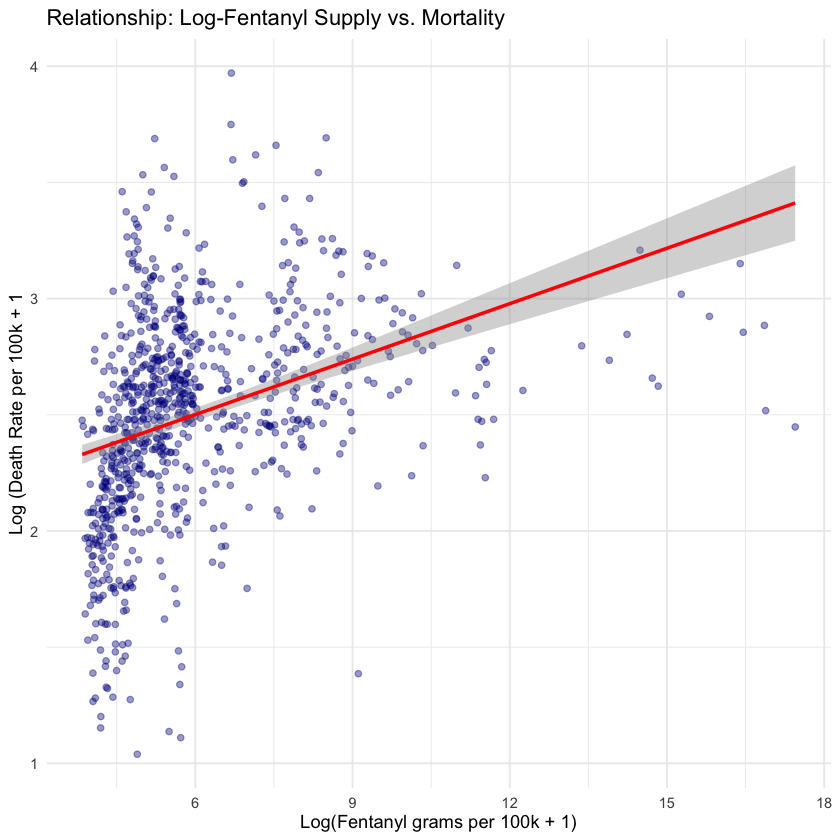

In [41]:
# Scatter plot of Log Fentanyl vs Death Rate
ggplot(df, aes(x = log_fent, y = log_death_rate)) +
  geom_point(alpha = 0.4, color = "darkblue") +
  geom_smooth(method = "lm", color = "red") + 
  labs(title = "Relationship: Log-Fentanyl Supply vs. Mortality",
       x = "Log(Fentanyl grams per 100k + 1)",
       y = "Log (Death Rate per 100k + 1") +
  theme_minimal()

## Multiple Linear Regression

In [46]:
head(df)

,year,state,pop,hydro_gms,oxy_gms,fent_gms,unempl_rate,poverty_rate,snap_rate,medicaid_rate,gsp_per_cap,min_wage,death_rate,log_hydro,log_oxy,log_fent,log_death_rate
,<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2000,AL,-0.2396840,-0.1037009,-0.07198984,-0.08602873,-0.73962867,0.1942059,-0.38573312,-0.62386327,-1.6618041,-1.026754,-1.308400,-0.3974345,-0.9192862,-0.9234053,-1.787006
2,2001,AL,-0.2373706,-0.1035686,-0.07195101,-0.08602885,-0.49287538,0.9488591,-0.31689900,-0.18631157,-1.6108019,-1.026754,-1.241686,-0.3637661,-0.8364945,-0.9250998,-1.627562
3,2002,AL,-0.2355071,-0.1032225,-0.07193209,-0.08601729,-0.13312766,0.5559496,-0.16282797,0.06299210,-1.5138153,-1.026754,-1.262992,-0.2837199,-0.8000439,-0.7838532,-1.677258
4,2003,AL,-0.2320056,-0.1028859,-0.07191409,-0.08600594,-0.07274793,0.6885560,-0.03373072,0.09102397,-1.4083021,-1.026754,-1.317015,-0.2149542,-0.7673390,-0.6757568,-1.808450
5,2004,AL,-0.2279301,-0.1025557,-0.07189656,-0.08599476,-0.22717372,1.3322157,0.07729171,0.21132943,-1.1632969,-1.026754,-1.001213,-0.1543956,-0.7371711,-0.5882937,-1.132110
6,2005,AL,-0.2220834,-0.1022392,-0.07188020,-0.08598392,-0.83051811,1.2020409,0.35266288,0.28930908,-0.9977787,-1.026754,-1.004699,-0.1015865,-0.7103351,-0.5160579,-1.138560


In [47]:
lmod <- lm(log_death_rate ~ log_hydro + log_oxy + log_fent +
             unempl_rate + poverty_rate + snap_rate + medicaid_rate +
             gsp_per_cap + min_wage, data = df)
summary(lmod)
vif(lmod)


Call:
lm(formula = log_death_rate ~ log_hydro + log_oxy + log_fent + 
    unempl_rate + poverty_rate + snap_rate + medicaid_rate + 
    gsp_per_cap + min_wage, data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.95995 -0.45580 -0.01585  0.50262  2.71473 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)    5.303e-17  2.664e-02   0.000  1.00000    
log_hydro     -1.107e-01  4.455e-02  -2.485  0.01314 *  
log_oxy        2.551e-01  4.422e-02   5.769 1.12e-08 ***
log_fent       7.670e-02  3.447e-02   2.225  0.02631 *  
unempl_rate    1.442e-02  3.210e-02   0.449  0.65349    
poverty_rate   4.132e-02  4.524e-02   0.913  0.36131    
snap_rate      2.711e-01  5.432e-02   4.991 7.30e-07 ***
medicaid_rate  8.156e-02  4.041e-02   2.018  0.04387 *  
gsp_per_cap    9.657e-02  3.727e-02   2.591  0.00973 ** 
min_wage       1.405e-01  4.439e-02   3.165  0.00160 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual stand

log_hydro       log_oxy      log_fent   unempl_rate  poverty_rate 
     2.793549      2.752106      1.672110      1.450601      2.881437 
    snap_rate medicaid_rate   gsp_per_cap      min_wage 
     4.153380      2.298464      1.954981      2.773703

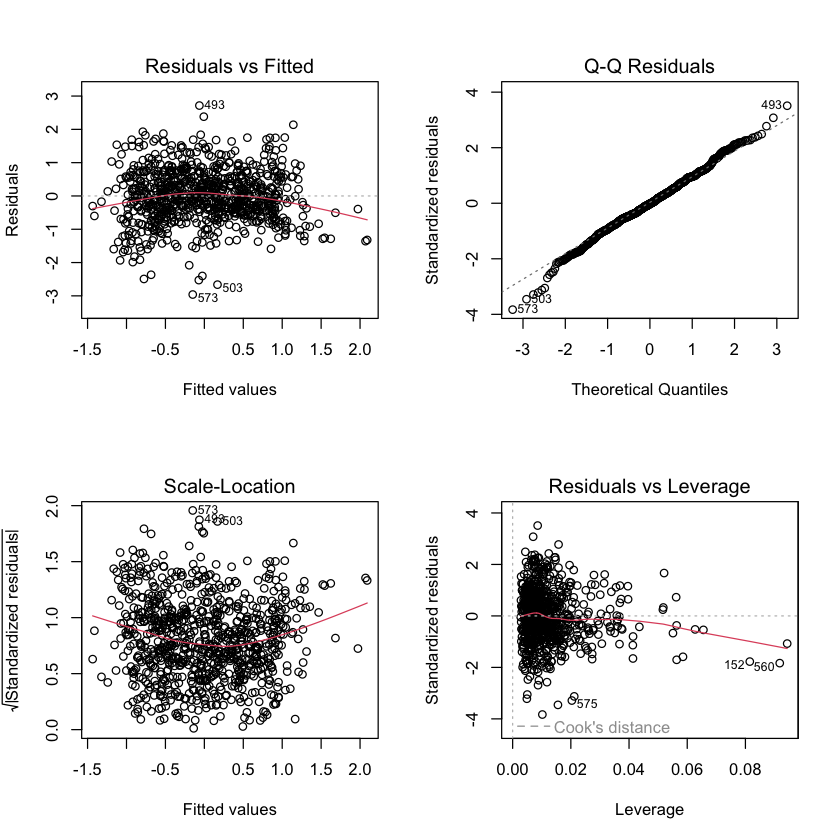

In [ ]:
# Diagnostic Plots
par(mfrow = c(2, 2))
plot(lmod)

In [53]:
# Best Subsets Regression
subsets <- regsubsets(log_death_rate ~ log_hydro + log_oxy + log_fent +
                        unempl_rate + poverty_rate + snap_rate + medicaid_rate +
                        gsp_per_cap + min_wage,
                      data = df,
                      nvmax = 9)

summary_subsets <- summary(subsets)

best_model_idx <- which.min(summary_subsets$bic)

summary_subsets$which[best_model_idx, ]

(Intercept)     log_hydro       log_oxy      log_fent   unempl_rate 
         TRUE         FALSE          TRUE         FALSE         FALSE 
 poverty_rate     snap_rate medicaid_rate   gsp_per_cap      min_wage 
        FALSE          TRUE         FALSE         FALSE          TRUE

In [60]:
# Ideal MLR Model
lmod_best <- lm(log_death_rate ~ log_oxy + snap_rate + min_wage, data = df)
summary(lmod_best)


Call:
lm(formula = log_death_rate ~ log_oxy + snap_rate + min_wage, 
    data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-3.02474 -0.45894 -0.00835  0.49900  2.74431 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 1.796e-16  2.684e-02   0.000        1    
log_oxy     2.398e-01  3.200e-02   7.495 1.67e-13 ***
snap_rate   2.951e-01  3.316e-02   8.901  < 2e-16 ***
min_wage    2.350e-01  3.225e-02   7.288 7.20e-13 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.7824 on 846 degrees of freedom
Multiple R-squared:   0.39,	Adjusted R-squared:  0.3879 
F-statistic: 180.3 on 3 and 846 DF,  p-value: < 2.2e-16


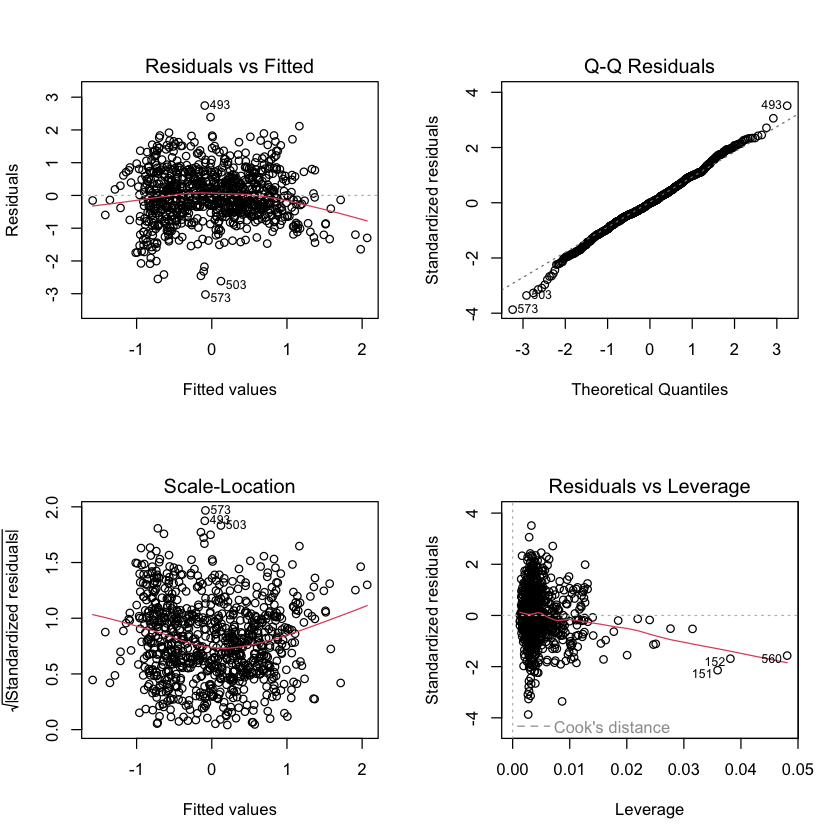

In [61]:
par(mfrow = c(2, 2))
plot(lmod_best)

In [69]:
dwtest(lmod_best)


	Durbin-Watson test

data:  lmod_best
DW = 0.46112, p-value < 2.2e-16
alternative hypothesis: true autocorrelation is greater than 0


In [66]:
vif(lmod_best)

log_oxy snap_rate  min_wage 
 1.419797  1.524675  1.442325

In [65]:
# Shapiro-Wilk Test for Normality of Residuals
residuals = resid(lmod_best)
shapiro.test((residuals))


	Shapiro-Wilk normality test

data:  (residuals)
W = 0.99507, p-value = 0.007586


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


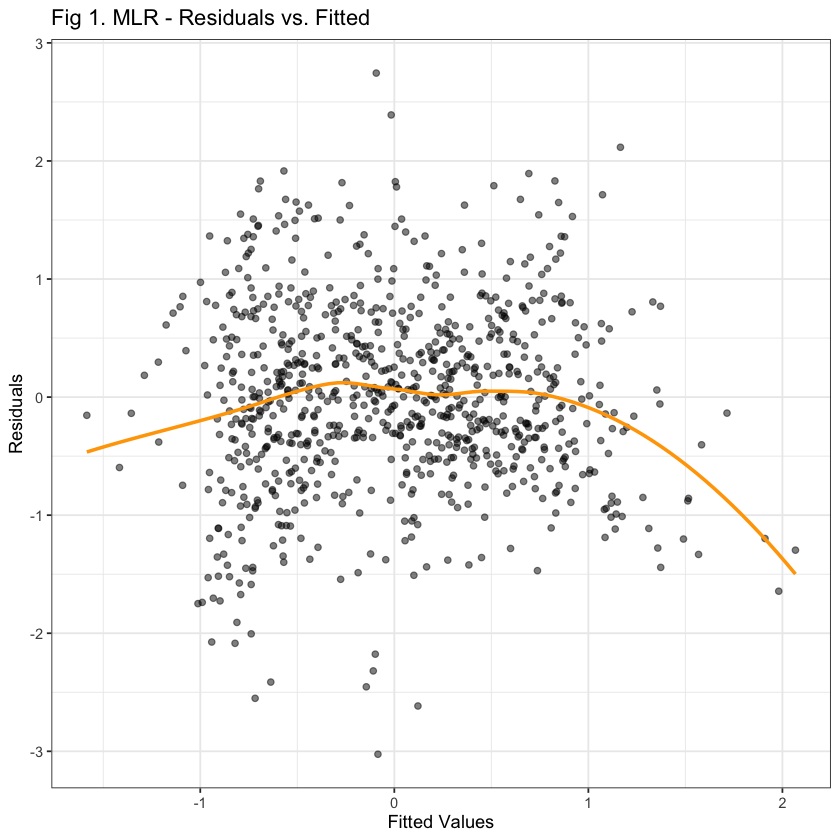

In [62]:
# --------------------- MLR Plots --------------------- #
df.diagnostics = data.frame(yhat = fitted(lmod_best),
                            r = resid(lmod_best),
                            y = df$log_death_rate,
                            oxy = df$log_oxy,
                            mw = df$min_wage,
                            snap = df$snap_rate)

# Residuals vs. Fitted
ggplot(df.diagnostics, aes(x = yhat, y = r)) +
  geom_point(alpha = 0.5) +
  xlab("Fitted Values") +
  ylab("Residuals") +
  geom_smooth(se = FALSE, col = "orange") +
  theme_bw() +
  ggtitle("Fig 1. MLR - Residuals vs. Fitted")

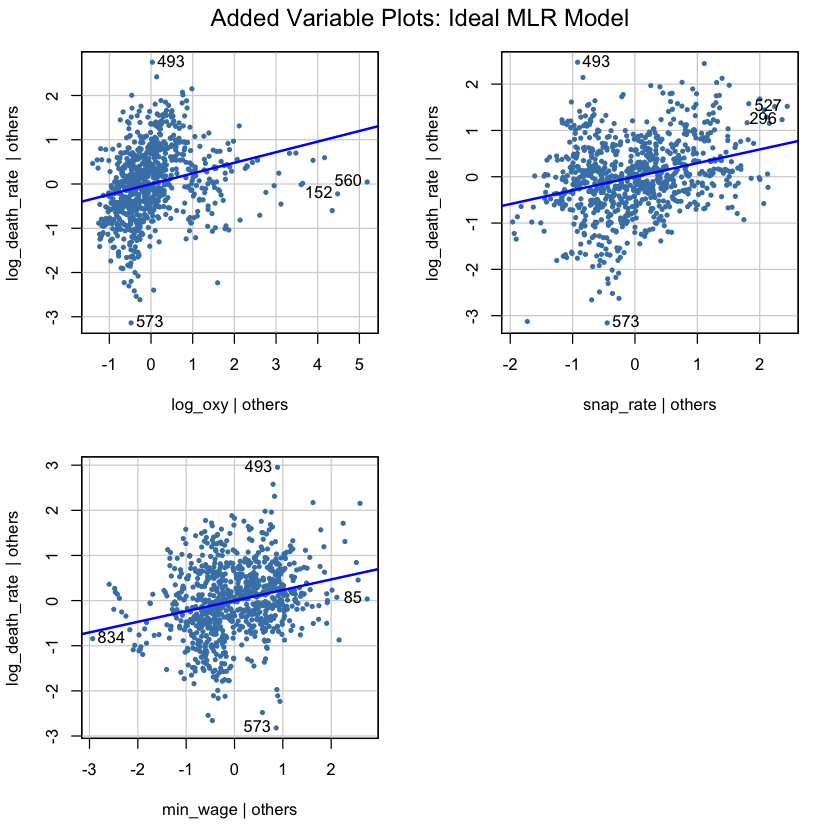

In [63]:
# Added Variable Plots
avPlots(lmod_best,
        col = "steelBlue",
        pch = 16,
        cex = 0.7,
        main = "Added Variable Plots: Ideal MLR Model")

In [64]:
# Check the top outliers
df[c(493, 573, 152, 560, 834), c("state", "year", "log_death_rate", "snap_rate", "log_oxy")]

,state,year,log_death_rate,snap_rate,log_oxy
,<fct>,<int>,<dbl>,<dbl>,<dbl>
493,NH,2016,2.6511535,-0.7319603,-0.07167318
573,ND,2011,-3.1091925,-0.3874926,-0.45928119
152,FL,2015,0.7708239,1.6547175,5.39370226
560,NC,2015,0.7125978,1.2815807,5.80486971
834,WY,2000,-1.7387800,-1.3519681,-1.24953689
